## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Supplementary Figure 4: Monthly import and expert in Switzerland in 2050 under various HP deployment
scenarios.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

### Supplementary Figure 4: Monthly import and expert in Switzerland in 2050 under various HP deployment

C:\Users\Administrator\AppData\Local\Temp\ipykernel_45364\1756529693.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45364\1756529693.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45364\1756529693.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_45364\1756529693.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=f'{year}-01-01

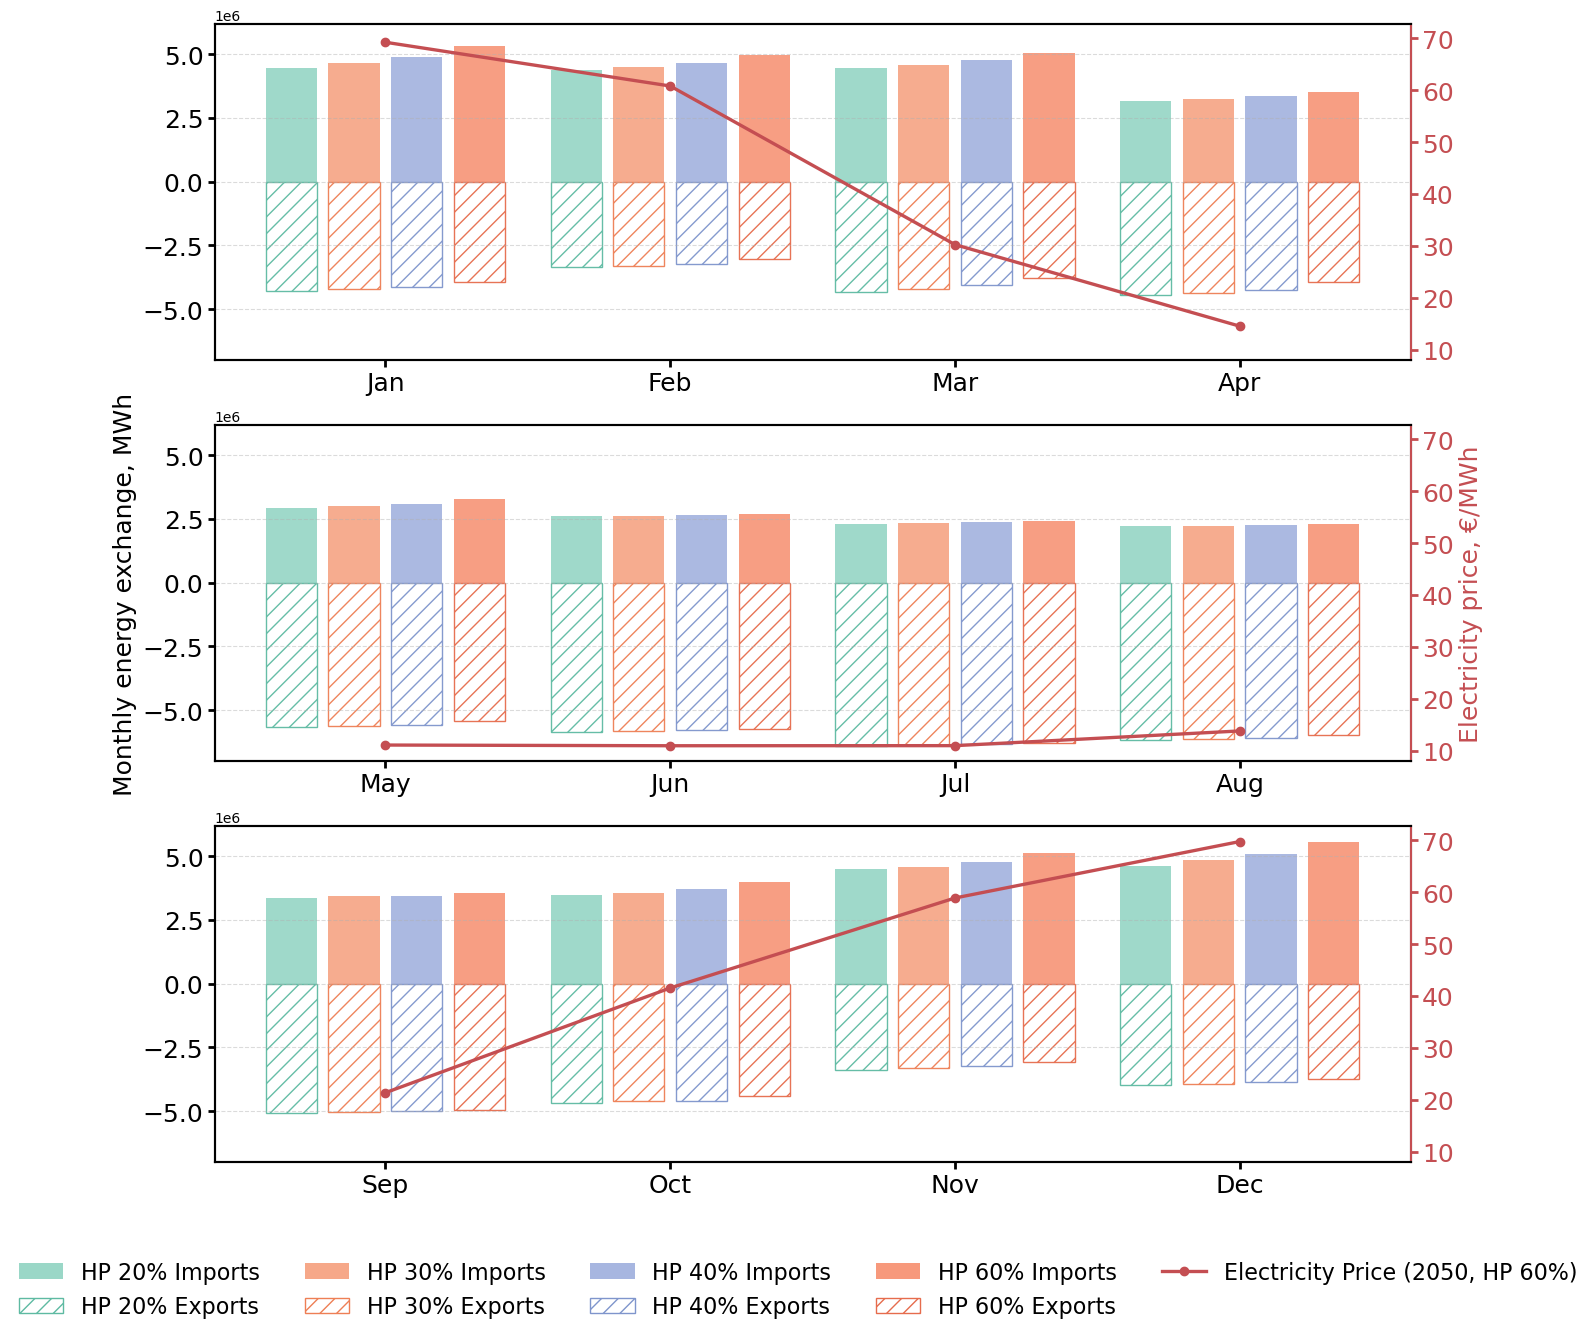

In [1]:
# ================================================================================
# This cell analyses and visualizes the results as shown in Supplementary Figure 4
# ================================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import matplotlib as mpl
from pathlib import Path
import os
# ========== Style helper function =========
tick_font_size = 18

def apply_axis_style(ax, axis_color='black', tick_dir='out'):
    """
    Apply a unified axis style.
    - All four spines are black by default. When axis_color is not black, the right spine and right-axis elements are colored accordingly.
    - The x-axis ticks and labels remain black, while the y-axis uses axis_color.
    """
    # Set all spines to black first
    for spine in ['bottom', 'top', 'left', 'right']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.5)

    # If this is the right axis, color the right spine and y-axis label
    if axis_color != 'black':
        ax.spines['right'].set_color(axis_color)
        ax.yaxis.label.set_color(axis_color)

    # Tick marks and label text
    ax.tick_params(axis='x', which='major',
                   pad=3, width=2, length=5,
                   direction=tick_dir, color='black',
                   labelsize=tick_font_size, labelcolor='black')

    ax.tick_params(axis='y', which='major',
                   pad=3, width=2, length=5,
                   direction=tick_dir, color=axis_color,
                   labelsize=tick_font_size, labelcolor=axis_color)

    # Axis labels
    ax.xaxis.label.set_color('black')
    # y Axis labelscolor has already been handled above based on axis_color

# ========== Base path and scenario mapping =========
root = Path(r"..\Output_data\power systems results")

case_mapping = {
    'HP 20%': 'case1a0',
    'HP 30%': 'case1b0',
    'HP 40%': 'case1c0',
    'HP 60%': 'case1d0',
}

# ========== Adjusted color scheme (soft fills with slightly lighter outlines) =========
palette = {
    'HP 20%': {'fill': '#9AD7C7', 'edge': '#5EBAA2'},
    'HP 30%': {'fill': '#F6A889', 'edge': '#EE7F55'},
    'HP 40%': {'fill': '#A7B6E0', 'edge': '#7F95CC'},
    'HP 60%': {'fill': '#F7997C', 'edge': '#E66C4D'},
}

# ========== I/O utilities =========
def load_hourly_skip_first(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=1, header=None, names=['Hour', 'Value'], usecols=[0, 1])
    df['Hour']  = pd.to_numeric(df['Hour'], errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df = df.dropna(subset=['Hour', 'Value']).reset_index(drop=True)
    df['Hour'] = df['Hour'].astype(int)
    return df

def month_index_from_hour(hour_series: pd.Series, year="2050") -> pd.Series:
    # Map hourly indices from 0 to 8759 to months
    date_range = pd.date_range(start=f'{year}-01-01 00:00:00', periods=8760, freq='H')
    map_0to = pd.Series(date_range.month, index=range(0, 8760))
    return hour_series.map(map_0to)

def load_monthly_exports_imports(case_name: str):
    base_case = root / case_name / "CentIv_2050"
    exports_file = base_case / "0-CH_exports.csv"
    imports_file = base_case / "0-CH_imports.csv"

    df_exports = load_hourly_skip_first(exports_file)
    df_imports = load_hourly_skip_first(imports_file)

    df_exports['Month'] = month_index_from_hour(df_exports['Hour'])
    df_imports['Month'] = month_index_from_hour(df_imports['Hour'])

    monthly_exports = df_exports.groupby('Month')['Value'].sum().reindex(range(1, 13)).values
    monthly_imports = df_imports.groupby('Month')['Value'].sum().reindex(range(1, 13)).values
    return monthly_exports, monthly_imports

def load_monthly_price(case_name: str):
    price_file = root / case_name / "national_generation_and_capacity" / "0-national_elecprice_monthly_c_2050.csv"
    price_file = os.path.abspath(price_file)
    df_price = pd.read_csv(price_file, usecols=['Month', 'Switzerland'])
    df_price.rename(columns={'Switzerland': 'Price'}, inplace=True)
    df_price['Month'] = pd.to_numeric(df_price['Month'], errors='coerce').astype('Int64')
    df_price['Price'] = pd.to_numeric(df_price['Price'], errors='coerce')
    df_price = df_price.dropna().astype({'Month': 'int'}).sort_values('Month')
    return df_price.set_index('Month').reindex(range(1, 13))['Price'].values

# ========== Load data =========
data = {}
for hp_label, case in case_mapping.items():
    exp, imp = load_monthly_exports_imports(case)
    data[hp_label] = {"exp": exp, "imp": imp}

# Use electricity prices only from the HP 60% case
price_case = case_mapping['HP 60%']
price_2050 = load_monthly_price(price_case)

# ========== Figure setup and styling =========
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_blocks = [(1,4), (5,8), (9,12)]

# Default font
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
})

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharey=True)

# —— Adjustable bar width —— #
bar_width_factor = 1.0      # Can be adjusted as needed, e.g., 0.8 or 1.2
base_bar_width  = 0.18 * bar_width_factor
inner_gap       = 0.04 * bar_width_factor

S = len(case_mapping)
group_width = S * base_bar_width + (S - 1) * inner_gap
centers = np.linspace(-group_width/2 + base_bar_width/2,
                      group_width/2 - base_bar_width/2, S)

# Electricity-price styling
price_line_color = '#C44E52'
price_marker = 'o'

# Y-axis limits
all_vals = np.concatenate([np.concatenate([v["exp"], v["imp"]]) for v in data.values()])
ymin, ymax = all_vals.min(), all_vals.max()
ypad = 0.05 * (ymax - ymin if ymax != ymin else 1.0)
pmin, pmax = price_2050.min(), price_2050.max()
ppad = 0.05 * (pmax - pmin if pmax != pmin else 1.0)

# ========== Plotting =========
for ax_idx, (m1, m2) in enumerate(month_blocks):
    ax1 = axes[ax_idx]
    months = np.arange(m1, m2 + 1)

    # Imports are filled with no border, while Exports are hollow with colored borders and hatching
    for si, hp_label in enumerate(case_mapping.keys()):
        colors = palette[hp_label]
        offset  = centers[si]
        exp_seg = data[hp_label]["exp"][m1-1:m2]
        imp_seg = data[hp_label]["imp"][m1-1:m2]

        # Imports (soft fill, no border)
        ax1.bar(months + offset, imp_seg, width=base_bar_width,
                color=colors['fill'], edgecolor='none', alpha=0.95,
                label=f"{hp_label} Imports" if ax_idx == 0 else "")
        # Exports (hollow bars with light-colored borders and hatching)
        ax1.bar(months + offset, exp_seg, width=base_bar_width,
                facecolor='none', edgecolor=colors['edge'], hatch='//', alpha=0.95,
                label=f"{hp_label} Exports" if ax_idx == 0 else "")

    # Left-axis styling
    ax1.set_xlim(m1-0.6, m2+0.6)
    ax1.set_ylim(ymin - ypad, ymax + ypad)
    ax1.set_xticks(months)
    ax1.set_xticklabels(months_labels[m1-1:m2])
    ax1.grid(axis='y', linestyle='--', alpha=0.45)
    apply_axis_style(ax1, axis_color='black', tick_dir='out')

    # Display the left-axis label only on the middle subplot
    if ax_idx == 1:
        ax1.set_ylabel('Monthly energy exchange, MWh')
    else:
        ax1.set_ylabel('')

    # Right axis: electricity price (all axis elements in red, with one major tick every 10 €/MWh)
    ax2 = ax1.twinx()
    price_seg = price_2050[m1-1:m2]
    ax2.plot(months, price_seg, color=price_line_color, marker=price_marker, linewidth=2.4,
             label="Electricity Price (2050, HP 60%)" if ax_idx == 0 else "")
    ax2.set_ylim(pmin - ppad, pmax + ppad)
    ax2.yaxis.set_major_locator(MultipleLocator(10))  # <<< One major tick every 10 €/MWh
    apply_axis_style(ax2, axis_color=price_line_color, tick_dir='out')
    if ax_idx == 1:
        ax2.set_ylabel('Electricity price, €/MWh')
    else:
        ax2.set_ylabel('')

# ========== Legend and layout =========
legend_handles = []
for hp_label, colors in palette.items():
    legend_handles.append(Patch(facecolor=colors['fill'], edgecolor='none', label=f"{hp_label} Imports"))
    legend_handles.append(Patch(facecolor='none', edgecolor=colors['edge'], hatch='//', label=f"{hp_label} Exports"))
line_proxy = plt.Line2D([0],[0], color=price_line_color, marker=price_marker, linewidth=2.4,
                        label='Electricity Price (2050, HP 60%)')
legend_handles.append(line_proxy)

fig.legend(handles=legend_handles, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
# ========== Additional step: export as SVG (text remains editable and is not converted to outlines) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Do not use LaTeX rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "figure_for_AI.svg"

# # Save as SVG with a transparent background and tight margins
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ========== plt.show()

